# 09. Support Vector Machines (SVM): Classification and Regression
**Algorithm Covered:**
- **Support Vector Machine (SVM)**
  1. **Support Vector Classification (SVC)** with Linear, Polynomial, and RBF Kernels
  2. **Support Vector Regression (SVR)** with $\epsilon$-Insensitive Tube

**Core Focus:**
- Maximum margin hyperplane optimization and soft-margin slack variables ($\xi_i$)
- Kernel Trick mapping non-linearly separable data into high-dimensional Hilbert spaces
- Support vector identification, margin geometry, and dual formulation
- Hyperparameter sensitivity analysis ($C$, $\gamma$, $\epsilon$)


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Datasets + model selection ----
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
# ---- SVM models: classification and regression ----
from sklearn.svm import SVC, SVR
# ---- Evaluation metrics ----
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, root_mean_squared_error

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("SVM modules loaded successfully!")


SVM modules loaded successfully!


## PART 1: Support Vector Classification (SVC)
### Mathematical Formulation
Given training pairs $\{(x_i, y_i)\}$ with $y_i \in \{-1, +1\}$, soft-margin SVC solves the primal quadratic program:
$$\min_{w, b, \xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^n \xi_i$$
$$\text{subject to } y_i(w^T \phi(x_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$
Using Lagrange multipliers $\alpha_i$, the dual formulation depends strictly on inner products:
$$\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i, j} \alpha_i \alpha_j y_i y_j K(x_i, x_j) \quad \text{s.t.} \quad 0 \le \alpha_i \le C, \; \sum \alpha_i y_i = 0$$
Only samples with $\alpha_i > 0$ become **Support Vectors**, lying on or violating the margin boundaries.


### Step-by-Step Algorithm (Support Vector Classification)
1. **Formulate** the soft-margin problem: minimize ½||w||² + C Σ ξ_i subject to y_i(wᵀφ(x_i)+b) ≥ 1 − ξ_i, ξ_i ≥ 0.
2. **Solve** the dual quadratic program with Lagrange multipliers α_i (convex -> global optimum).
3. **Identify support vectors:** training points with α_i > 0; they lie on or inside the margin.
4. **Kernel trick:** replace inner products with K(x_i, x_j) (linear, polynomial, RBF, ...) to model non-linear boundaries.
5. **Predict:** class = sign(Σ α_i y_i K(x_i, x) + b).
6. **Tune** C and γ by cross-validation to balance margin width and violations.


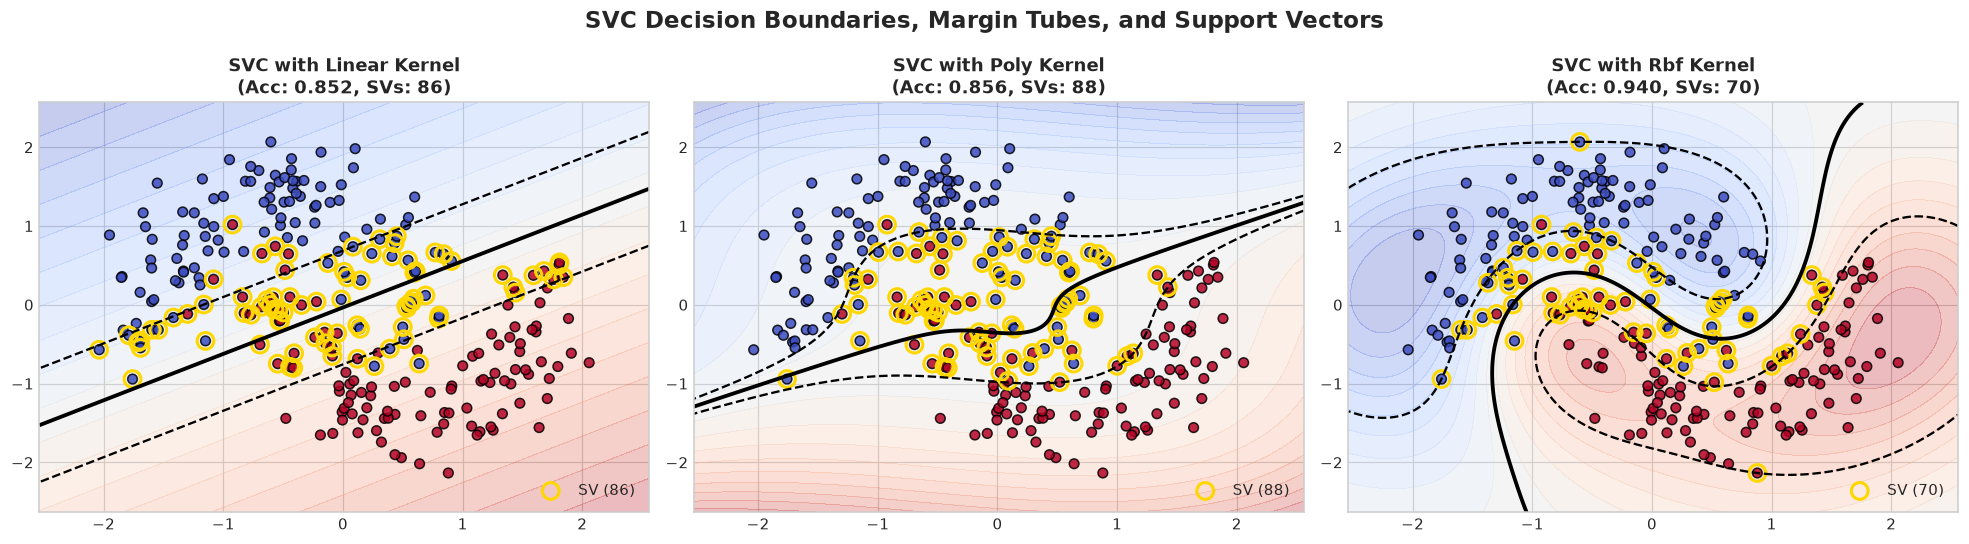

In [2]:
# ---- 2D synthetic data for visualizing margins and kernels ----
# Two interleaving half-moons cannot be separated by a straight line.
X_2d, y_2d = make_moons(n_samples=250, noise=0.20, random_state=42)
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coordinate grid used to draw the decision boundary as a contour
x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for ax, k_name in zip(axes, kernels):
    # Train one SVC per kernel on the same data
    clf = SVC(kernel=k_name, C=1.0, gamma='scale', degree=3, random_state=42)
    clf.fit(X_2d_scaled, y_2d)

    # Signed distance to the hyperplane for every grid point
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Filled contour = decision regions; solid line = boundary (Z=0); dashed = margins (Z=±1)
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='coolwarm', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0], linestyles=['--', '-', '--'], colors=['k', 'k', 'k'], linewidths=[1.5, 2.5, 1.5])

    # Scatter the data points (colored by class)
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap='coolwarm', edgecolors='k', s=40, alpha=0.85)

    # Highlight the support vectors (the points that define the margin)
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='gold', linewidths=2.0, label=f'SV ({len(sv)})')

    ax.set_title(f"SVC with {k_name.capitalize()} Kernel\n(Acc: {clf.score(X_2d_scaled, y_2d):.3f}, SVs: {len(sv)})", fontweight='bold')
    ax.legend(loc='lower right')

plt.suptitle("SVC Decision Boundaries, Margin Tubes, and Support Vectors", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.2 SVC on High-Dimensional Diagnostic Benchmark
We evaluate SVC across kernels on the **Breast Cancer** dataset (30 features).


In [3]:
# ---- High-dimensional benchmark: Breast Cancer dataset (30 features) ----
cancer = load_breast_cancer()
X_c = cancer.data
y_c = cancer.target

# Stratified split + scaling (SVM is distance-based, scaling is essential)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.25, random_state=42, stratify=y_c)
scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# ---- Train one SVC per kernel and record test accuracy + support-vector usage ----
kernel_results = []
for k in ['linear', 'poly', 'rbf', 'sigmoid']:
    model = SVC(kernel=k, C=1.0, random_state=42)
    model.fit(X_train_c_s, y_train_c)
    acc = model.score(X_test_c_s, y_test_c)
    kernel_results.append({
        "Kernel": k.capitalize(),
        "Test Accuracy": acc,
        "Support Vectors": len(model.support_),                                 # number of support vectors
        "SV Ratio": f"{len(model.support_) / len(X_train_c) * 100:.1f}%"       # share of training data
    })

df_k = pd.DataFrame(kernel_results).set_index("Kernel")
print("SVC Kernel Benchmark on Breast Cancer Dataset:")
# Green = highest accuracy and fewest support vectors (sparser solution)
display(df_k.style.highlight_max(subset=['Test Accuracy'], color='lightgreen')
                   .highlight_min(subset=['Support Vectors'], color='lightgreen'))


SVC Kernel Benchmark on Breast Cancer Dataset:


,Test Accuracy,Support Vectors,SV Ratio
Kernel,,,
Linear,0.986014,34,8.0%
Poly,0.902098,136,31.9%
Rbf,0.979021,96,22.5%
Sigmoid,0.951049,65,15.3%


### 1.3 Hyperparameter Tuning ($C$ and $\gamma$)
- **$C$ (Cost parameter):** Controls the tradeoff between smooth decision boundary and margin violation penalty. Large $C$ creates tight, complex margins; small $C$ permits more violations for a wider margin.
- **$\gamma$ (Gamma for RBF kernel):** Controls the radius of influence of each support vector. Large $\gamma$ creates localized, high-variance boundaries; small $\gamma$ behaves more linearly.


### Hyperparameter Tuning Process (Grid Search)
1. Define a grid over C (violation penalty) and γ (RBF width).
2. For each pair, run 5-fold cross-validation on the training set and average the validation accuracy.
3. Select the pair with the best mean CV score.
4. Refit the final model and visualize the CV-accuracy heatmap.


Best Parameters: {'C': 10, 'gamma': 0.001}
Best 5-Fold CV Accuracy: 0.9765


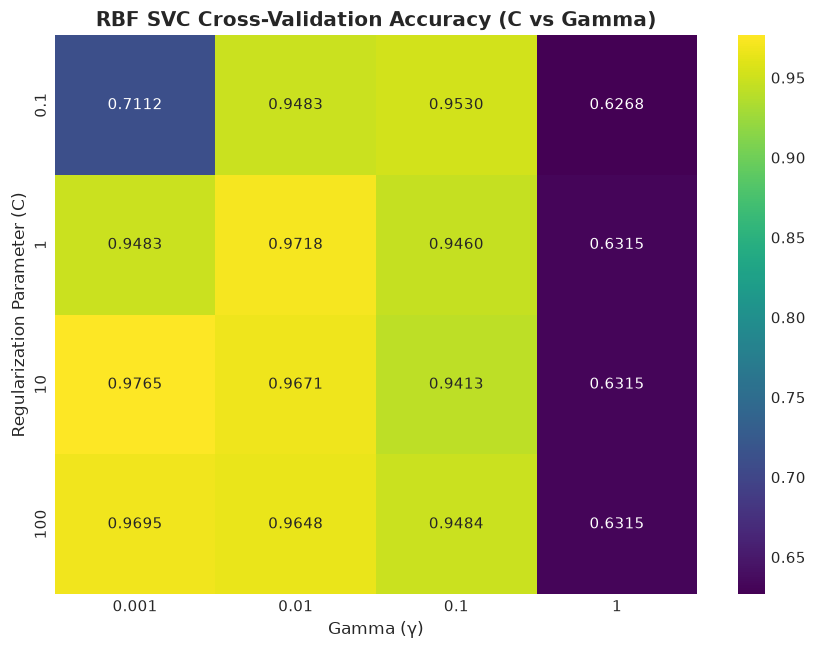

In [4]:
# ---- Grid search over the two key RBF hyperparameters ----
# C     : penalty for margin violations (bias/variance trade-off)
# gamma : RBF kernel width (how far the influence of one support vector reaches)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# 5-fold cross-validation on the training set for every (C, gamma) combination
grid_svc = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=5, scoring='accuracy')
grid_svc.fit(X_train_c_s, y_train_c)

print("Best Parameters:", grid_svc.best_params_)
print(f"Best 5-Fold CV Accuracy: {grid_svc.best_score_:.4f}")

# Reshape the CV scores into a (C x gamma) matrix for the heatmap
scores_matrix = grid_svc.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.4f', cmap='viridis',
            xticklabels=param_grid['gamma'], yticklabels=param_grid['C'])
plt.title("RBF SVC Cross-Validation Accuracy (C vs Gamma)", fontsize=13, fontweight='bold')
plt.xlabel("Gamma (γ)", fontsize=11)
plt.ylabel("Regularization Parameter (C)", fontsize=11)
plt.tight_layout()
plt.show()


## PART 2: Support Vector Regression (SVR)
### Mathematical Formulation
In SVR, errors within an **$\epsilon$-insensitive tube** are ignored without penalty ($|y_i - f(x_i)| \le \epsilon$).
For deviations exceeding $\epsilon$, slack variables $\xi_i, \xi_i^*$ incur a linear penalty:
$$\min_{w, b, \xi, \xi^*} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$
$$\text{s.t. } y_i - (w^T \phi(x_i) + b) \le \epsilon + \xi_i, \quad (w^T \phi(x_i) + b) - y_i \le \epsilon + \xi_i^*, \quad \xi_i, \xi_i^* \ge 0$$
Samples residing outside the $\epsilon$-tube become the **Support Vectors** that anchor the regression surface.


### Step-by-Step Algorithm (Support Vector Regression)
1. Define an ε-insensitive tube: residuals with |y_i − f(x_i)| ≤ ε incur zero loss.
2. Minimize ½||w||² + C Σ (ξ_i + ξ_i*) subject to the tube constraints.
3. Solve the dual; only points on/outside the tube get α_i > 0 and become support vectors.
4. **Predict:** f(x) = Σ α_i K(x_i, x) + b (kernel regression).
5. Visualize the fitted curve, the ±ε tube, and the support vectors.


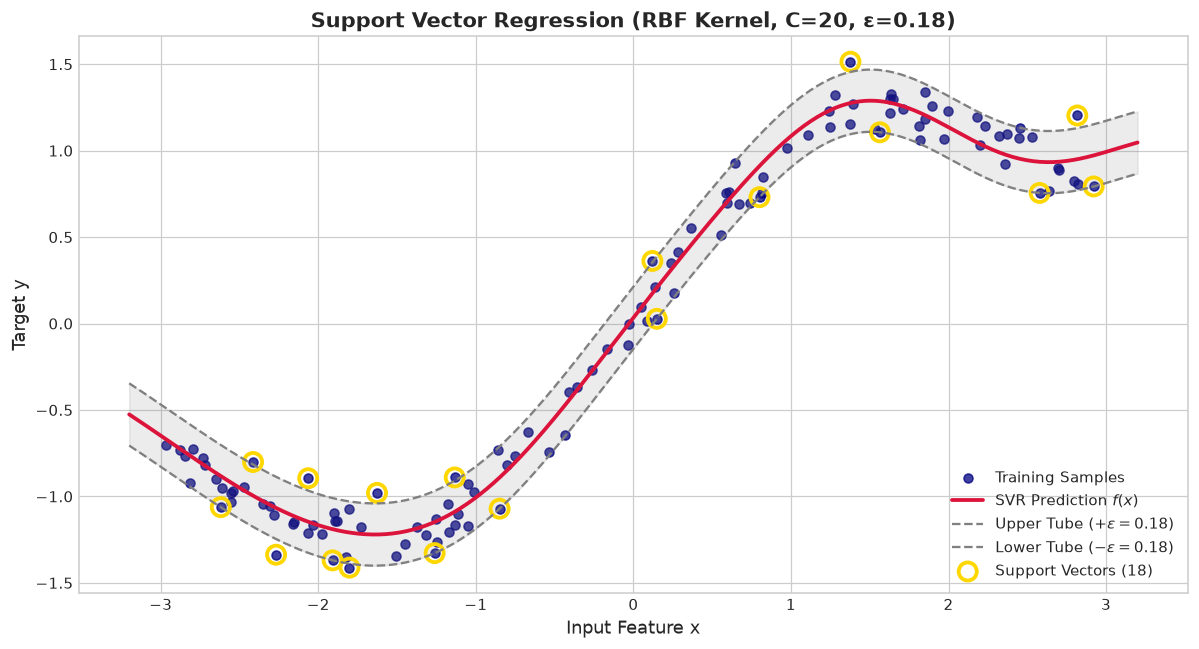

SVR R² Score: 0.9864
SVR RMSE:     0.1157
Support Vectors: 18 out of 120 points (15.0%)


In [5]:
# ---- 1D non-linear regression demonstration ----
np.random.seed(42)
# Synthetic target: sine + linear trend + Gaussian noise
X_svr = np.sort(np.random.uniform(-3, 3, 120)).reshape(-1, 1)
y_svr = np.sin(X_svr).ravel() + 0.15 * X_svr.ravel() + np.random.normal(0, 0.12, 120)

# epsilon defines the width of the "no penalty" tube around the prediction
epsilon_val = 0.18
svr_model = SVR(kernel='rbf', C=20.0, epsilon=epsilon_val, gamma=0.5)
svr_model.fit(X_svr, y_svr)

# Dense grid for drawing a smooth prediction curve
X_grid = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)
y_grid_pred = svr_model.predict(X_grid)

# Support vectors = training points that lie on/outside the epsilon tube
sv_indices = svr_model.support_
X_sv = X_svr[sv_indices]
y_sv = y_svr[sv_indices]

plt.figure(figsize=(11, 6))
# Training samples
plt.scatter(X_svr, y_svr, color='navy', s=35, alpha=0.75, label='Training Samples')

# Regression surface
plt.plot(X_grid, y_grid_pred, color='crimson', lw=2.5, label='SVR Prediction $f(x)$')

# Epsilon-insensitive tube boundaries + shaded tube
plt.plot(X_grid, y_grid_pred + epsilon_val, color='gray', linestyle='--', lw=1.5, label=rf'Upper Tube ($+\epsilon={epsilon_val}$)')
plt.plot(X_grid, y_grid_pred - epsilon_val, color='gray', linestyle='--', lw=1.5, label=rf'Lower Tube ($-\epsilon={epsilon_val}$)')
plt.fill_between(X_grid.ravel(), y_grid_pred - epsilon_val, y_grid_pred + epsilon_val, color='gray', alpha=0.15)

# Support vectors are highlighted - only these points influence the fitted curve
plt.scatter(X_sv, y_sv, s=140, facecolors='none', edgecolors='gold', linewidths=2.5, label=f'Support Vectors ({len(X_sv)})')

plt.title(f"Support Vector Regression (RBF Kernel, C=20, ε={epsilon_val})", fontsize=14, fontweight='bold')
plt.xlabel("Input Feature x", fontsize=12)
plt.ylabel("Target y", fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ---- Quantitative evaluation ----
print(f"SVR R² Score: {r2_score(y_svr, svr_model.predict(X_svr)):.4f}")
print(f"SVR RMSE:     {root_mean_squared_error(y_svr, svr_model.predict(X_svr)):.4f}")
print(f"Support Vectors: {len(X_sv)} out of {len(X_svr)} points ({len(X_sv)/len(X_svr)*100:.1f}%)")


## 3. Conclusions & Key Takeaways
1. **Sparsity of Solution**: Both SVC and SVR depend only on a subset of training points (the support vectors); non-support points can be deleted without altering the learned function.
2. **Global Convexity**: Unlike neural networks with non-convex loss surfaces and local minima, SVM optimization is a convex quadratic program with a guaranteed global optimum.
3. **Kernel Flexibility**: The Kernel Trick enables linear algorithms to model arbitrarily complex, non-linear manifolds in feature space without explicitly computing high-dimensional coordinates.
